In [78]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [79]:
DATA_DIR = Path("../data")
VIDEO_DIR = DATA_DIR / "videos"
METADATA_FILE = DATA_DIR / "WLASL_v0.3.json"
MISSING_FILE = DATA_DIR / "missing.txt"

video_files = list(VIDEO_DIR.glob("*.mp4"))

print("Videos: ", len(video_files))
display(video_files[:5])

Videos:  11980


[WindowsPath('../data/videos/00335.mp4'),
 WindowsPath('../data/videos/00336.mp4'),
 WindowsPath('../data/videos/00338.mp4'),
 WindowsPath('../data/videos/00339.mp4'),
 WindowsPath('../data/videos/00341.mp4')]

In [80]:
import json

with open(METADATA_FILE, "r") as f:
    meta = json.load(f)

print("Metadata: ", len(meta), type(meta))

Metadata:  2000 <class 'list'>


In [81]:
display(meta[0])

{'gloss': 'book',
 'instances': [{'bbox': [385, 37, 885, 720],
   'fps': 25,
   'frame_end': -1,
   'frame_start': 1,
   'instance_id': 0,
   'signer_id': 118,
   'source': 'aslbrick',
   'split': 'train',
   'url': 'http://aslbricks.org/New/ASL-Videos/book.mp4',
   'variation_id': 0,
   'video_id': '69241'},
  {'bbox': [190, 25, 489, 370],
   'fps': 25,
   'frame_end': -1,
   'frame_start': 1,
   'instance_id': 1,
   'signer_id': 90,
   'source': 'aslsignbank',
   'split': 'train',
   'url': 'https://aslsignbank.haskins.yale.edu/dictionary/protected_media/glossvideo/ASL/BO/BOOK-418.mp4',
   'variation_id': 0,
   'video_id': '65225'},
  {'bbox': [262, 1, 652, 480],
   'fps': 25,
   'frame_end': -1,
   'frame_start': 1,
   'instance_id': 2,
   'signer_id': 110,
   'source': 'valencia-asl',
   'split': 'train',
   'url': 'https://www.youtube.com/watch?v=0UsjUE-TXns',
   'variation_id': 0,
   'video_id': '68011'},
  {'bbox': [123, 19, 516, 358],
   'fps': 25,
   'frame_end': 60,
   'frame

In [82]:
glosses = [item["gloss"] for item in meta]
print("Unique glosses: ", len(set(glosses))) #2000 

Unique glosses:  2000


In [83]:
import pandas as pd

records = []
for entry in meta:
    gloss = entry["gloss"]

    for instance in entry["instances"]:
        records.append({
            "video_id": instance["video_id"],
            "gloss": gloss,
            "split": instance["split"],
            "signer_id": instance["signer_id"]
        })

manifest = pd.DataFrame(records)

manifest.head()


,video_id,gloss,split,signer_id
0,69241,book,train,118
1,65225,book,train,90
2,68011,book,train,110
3,68208,book,train,113
4,68012,book,train,109


In [84]:
with open(MISSING_FILE) as f:
    missing_ids = {
        line.strip()
        for line in f
    }

print("Missing videos:", len(missing_ids))

manifest = manifest[
    ~manifest["video_id"].isin(missing_ids)
].reset_index(drop=True)

print("Remaining videos:", len(manifest))

Missing videos: 9103
Remaining videos: 11980


In [85]:
manifest["video_path"] = manifest["video_id"].apply(lambda vid: VIDEO_DIR / f"{vid}.mp4")
manifest.head()

,video_id,gloss,split,signer_id,video_path
0,69241,book,train,118,..\data\videos\69241.mp4
1,07069,book,train,31,..\data\videos\07069.mp4
2,07068,book,train,36,..\data\videos\07068.mp4
3,07070,book,train,59,..\data\videos\07070.mp4
4,07099,book,val,12,..\data\videos\07099.mp4


In [86]:
manifest["exists"] = manifest["video_path"].apply(lambda p: p.exists())
print("Videos that exist:", manifest["exists"].sum())

Videos that exist: 11980


In [87]:
manifest["split"].value_counts()

split
train    8313
val      2253
test     1414
Name: count, dtype: int64

In [88]:
manifest["gloss"].value_counts().head(20)

gloss
before          16
thin            16
cool            16
drink           15
go              15
computer        14
who             14
cousin          14
help            14
candy           13
thanksgiving    13
bed             13
bowling         13
tall            13
accident        13
short           13
trade           13
yes             12
what            12
later           12
Name: count, dtype: int64

In [89]:
classes = sorted(
    manifest["gloss"].unique()
)

label2id = {
    cls: idx
    for idx, cls in enumerate(classes)
}

id2label = {
    idx: cls
    for cls, idx in label2id.items()
}

In [90]:
manifest["label"] = manifest["gloss"].map(
    label2id
)

In [91]:
manifest[
    ["gloss", "label"]
].head()

,gloss,label
0,book,210
1,book,210
2,book,210
3,book,210
4,book,210


In [92]:
manifest.to_csv(
    "../data/manifest.csv",
    index=False
)

In [93]:
import pandas as pd
manifest = pd.read_csv("../data/manifest.csv")
manifest.head()

,video_id,gloss,split,signer_id,video_path,exists,label
0,69241,book,train,118,..\data\videos\69241.mp4,True,210
1,7069,book,train,31,..\data\videos\07069.mp4,True,210
2,7068,book,train,36,..\data\videos\07068.mp4,True,210
3,7070,book,train,59,..\data\videos\07070.mp4,True,210
4,7099,book,val,12,..\data\videos\07099.mp4,True,210


In [94]:
manifest.iloc[7]

video_id                         65539
gloss                            drink
split                            train
signer_id                           94
video_path    ..\data\videos\65539.mp4
exists                            True
label                              568
Name: 7, dtype: object

In [95]:
import cv2

video_path = manifest.iloc[0]["video_path"]

cap = cv2.VideoCapture(video_path)

print("Opened:", cap.isOpened())
print("Frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

ret, frame = cap.read()

print("Read frame:", ret)

cap.release()

Opened: True
Frames: 75
Read frame: True


In [96]:
def load_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    
    cap.release()
    return np.array(frames)

In [97]:
frames = load_video(video_path)
print(len(frames))

75


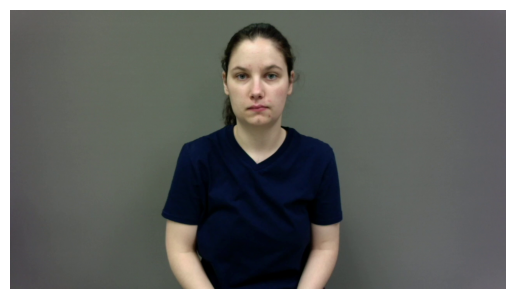

In [98]:
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(
    frames[0],
    cv2.COLOR_BGR2RGB
)

plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

In [102]:
err_vids = []

for _, row in manifest.sample(200).iterrows():

    cap = cv2.VideoCapture(
        str(VIDEO_DIR / f"{row['video_id']}.mp4")
    )
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if frame_count < 1: err_vids.append(row["video_id"])

print(len(err_vids), "videos with 0 frames")
print("Sample:", err_vids[:5])

23 videos with 0 frames
Sample: [3105, 5715, 3603, 5727, 8412]


In [103]:
bad_id = err_vids[0]

video_path = VIDEO_DIR / f"{bad_id}.mp4"

print(video_path)
print(video_path.exists())
print(video_path.stat().st_size if video_path.exists() else "missing")

..\data\videos\3105.mp4
False
missing


In [104]:
good_row = manifest[
    ~manifest["video_id"].isin(err_vids)
].iloc[0]

good_path = VIDEO_DIR / f"{good_row['video_id']}.mp4"

print(good_path.exists())
print(good_path.stat().st_size)

True
3012348


In [105]:
print(type(err_vids[0]))
print(err_vids[0])

<class 'int'>
3105


In [106]:
manifest = pd.read_csv(
    "../data/manifest.csv",
    dtype={"video_id": str}
)

In [107]:
from tqdm import tqdm

frame_counts = []

for _, row in tqdm(
    manifest.sample(200).iterrows(),
    total=200
):

    cap = cv2.VideoCapture(
        str(VIDEO_DIR / f"{row['video_id']}.mp4")
    )

    frame_counts.append(
        int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    )

    cap.release()

100%|██████████| 200/200 [00:05<00:00, 33.41it/s]


In [108]:
import numpy as np

print("Min :", np.min(frame_counts))
print("Mean:", np.mean(frame_counts))
print("Max :", np.max(frame_counts))
print("Median:", np.median(frame_counts))

Min : 20
Mean: 70.115
Max : 173
Median: 71.0


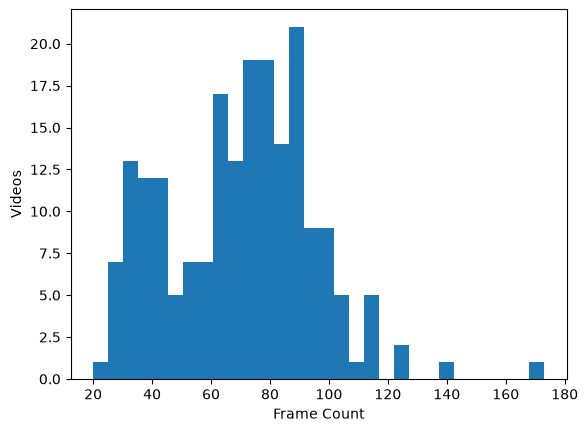

In [109]:
plt.hist(frame_counts, bins=30)
plt.xlabel("Frame Count")
plt.ylabel("Videos")
plt.show()

LETS USE SEQUENCE_LENGTH = 64

In [112]:
import numpy as np

def sample_video_frames(frames, seq_len=64):

    if len(frames) == 0:
        raise ValueError("Video contains no frames")

    indices = np.linspace(
        0,
        len(frames) - 1,
        seq_len
    ).astype(int)

    sampled = [
        frames[i]
        for i in indices
    ]

    return sampled

In [114]:
frames = load_video(video_path)

sampled_frames = sample_video_frames(
    frames,
    seq_len=64
)

print(len(sampled_frames))

ValueError: Video contains no frames

In [115]:
print(video_path)

cap = cv2.VideoCapture(str(video_path))

print("Opened:", cap.isOpened())

print("Frame count:",
      int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

ret, frame = cap.read()

print("First frame read:", ret)

cap.release()

..\data\videos\3105.mp4
Opened: False
Frame count: 0
First frame read: False


In [116]:
sample = manifest.iloc[0]

print(sample["video_id"])
print(video_path.exists())

69241
False


In [117]:
sample = manifest.iloc[0]

video_path = VIDEO_DIR / f"{sample['video_id']}.mp4"

print(video_path)

..\data\videos\69241.mp4


In [118]:
frames = load_video(video_path)

sampled_frames = sample_video_frames(
    frames,
    seq_len=64
)

print(len(sampled_frames))

64


In [121]:
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MODEL_PATH = "../models/hand_landmarker.task"

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

In [122]:
def extract_landmarks(frame):

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = detector.detect(mp_image)

    if len(result.hand_landmarks) > 0:

        hand = result.hand_landmarks[0]

        features = []

        for lm in hand:

            features.extend([
                lm.x,
                lm.y,
                lm.z
            ])

        return np.array(
            features,
            dtype=np.float32
        )

    return np.zeros(
        63,
        dtype=np.float32
    )

In [123]:
frame = sampled_frames[0]

landmarks = extract_landmarks(frame)

print(landmarks.shape)

(63,)


In [124]:
sequence = []

for frame in sampled_frames:

    sequence.append(
        extract_landmarks(frame)
    )

sequence = np.array(
    sequence,
    dtype=np.float32
)

print(sequence.shape)

(64, 63)


In [127]:
display(landmarks.shape)
display(sequence.shape)

(63,)

(64, 63)